In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r"C:\Users\navee\Desktop\python libraries\Projects series\csv data sets\Police Data Udemy.csv")
df = data.copy()
df

,stop_date,stop_time,country_name,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,NaN,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,1/18/2005,08:15,NaN,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
2,1/23/2005,23:15,NaN,M,1972.0,33.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
3,2/20/2005,17:15,NaN,M,1986.0,19.0,White,Call for Service,Other,False,NaN,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00,NaN,F,1984.0,21.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65530,12-06-2012,17:54,NaN,F,1987.0,25.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
65531,12-06-2012,22:22,NaN,M,1954.0,58.0,White,Speeding,Speeding,False,NaN,Warning,False,0-15 Min,False
65532,12-06-2012,23:20,NaN,M,1985.0,27.0,Black,Equipment/Inspection Violation,Equipment,False,NaN,Citation,False,0-15 Min,False
65533,12-07-2012,00:23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,False


In [3]:
df.shape

(65535, 15)

In [4]:
# check null values
df.isnull().sum()

stop_date                 0
stop_time                 0
country_name          65535
driver_gender          4061
driver_age_raw         4054
driver_age             4307
driver_race            4060
violation_raw          4060
violation              4060
search_conducted          0
search_type           63056
stop_outcome           4060
is_arrested            4060
stop_duration          4060
drugs_related_stop        0
dtype: int64

In [5]:
df.drop('country_name', axis=1, inplace=True)

In [6]:
df.head(2)

,stop_date,stop_time,driver_gender,driver_age_raw,driver_age,driver_race,violation_raw,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,M,1985.0,20.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False
1,1/18/2005,08:15,M,1965.0,40.0,White,Speeding,Speeding,False,NaN,Citation,False,0-15 Min,False


In [7]:
df['driver_age'].median()

31.0

In [8]:
# fill missing value of driver_age column with its median
df['driver_age'] = df['driver_age'].fillna(df['driver_age'].median())
# verify is there any NaN value
df['driver_age'].isnull().sum()

np.int64(0)

In [9]:
df[['violation_raw','violation']].head(10)

,violation_raw,violation
0,Speeding,Speeding
1,Speeding,Speeding
2,Speeding,Speeding
3,Call for Service,Other
4,Speeding,Speeding
5,Equipment/Inspection Violation,Equipment
6,Speeding,Speeding
7,Speeding,Speeding
8,Speeding,Speeding
9,Speeding,Speeding


In [10]:
df[['driver_age','driver_age_raw']].head(10)

,driver_age,driver_age_raw
0,20.0,1985.0
1,40.0,1965.0
2,33.0,1972.0
3,19.0,1986.0
4,21.0,1984.0
5,23.0,1982.0
6,36.0,1969.0
7,19.0,1986.0
8,35.0,1970.0
9,35.0,1970.0


In [11]:
df['driver_age_raw'].describe()

count    61481.000000
mean      1967.791106
std        121.050106
min          0.000000
25%       1965.000000
50%       1978.000000
75%       1985.000000
max       8801.000000
Name: driver_age_raw, dtype: float64

In [12]:
# ❌ Problems:
# min = 0.0 → age/birth year 0 impossible
# max = 8801.0 → completely invalid
# mean/std bhi weird (121 std is crazy high)

# 👉 iska matlab:
#ye column dirty / corrupted data hai

df.drop('driver_age_raw', axis=1, inplace=True)

In [13]:
df.drop('violation_raw', axis=1, inplace=True)

In [14]:
df.isnull().sum()

stop_date                 0
stop_time                 0
driver_gender          4061
driver_age                0
driver_race            4060
violation              4060
search_conducted          0
search_type           63056
stop_outcome           4060
is_arrested            4060
stop_duration          4060
drugs_related_stop        0
dtype: int64

_____________

In [15]:
df[df['driver_gender'].isnull()].head()

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
25,09-03-2005,16:02,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
29,9/26/2005,01:05,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
52,10-01-2005,13:09,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
110,10-03-2005,19:50,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
124,10-04-2005,11:43,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False


In [16]:
df[df['violation'].isnull()].head()

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
25,09-03-2005,16:02,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
29,9/26/2005,01:05,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
52,10-01-2005,13:09,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
110,10-03-2005,19:50,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False
124,10-04-2005,11:43,NaN,31.0,NaN,NaN,False,NaN,NaN,NaN,NaN,False


In [17]:
# remove incomplete records
df = df.dropna(subset=[
    'driver_gender',
    'driver_age',
    'driver_race',
    'violation',
    'stop_outcome',
    'is_arrested',
    'stop_duration'
])

In [18]:
df.isnull().sum()

stop_date                 0
stop_time                 0
driver_gender             0
driver_age                0
driver_race               0
violation                 0
search_conducted          0
search_type           58995
stop_outcome              0
is_arrested               0
stop_duration             0
drugs_related_stop        0
dtype: int64

In [19]:
df['search_type'] = df['search_type'].fillna('No Search')

In [20]:
df.isnull().sum()

stop_date             0
stop_time             0
driver_gender         0
driver_age            0
driver_race           0
violation             0
search_conducted      0
search_type           0
stop_outcome          0
is_arrested           0
stop_duration         0
drugs_related_stop    0
dtype: int64

In [21]:
df

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,M,20.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
1,1/18/2005,08:15,M,40.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
2,1/23/2005,23:15,M,33.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
3,2/20/2005,17:15,M,19.0,White,Other,False,No Search,Arrest Driver,True,16-30 Min,False
4,3/14/2005,10:00,F,21.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
...,...,...,...,...,...,...,...,...,...,...,...,...
65529,12-06-2012,16:00,M,18.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
65530,12-06-2012,17:54,F,25.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
65531,12-06-2012,22:22,M,58.0,White,Speeding,False,No Search,Warning,False,0-15 Min,False
65532,12-06-2012,23:20,M,27.0,Black,Equipment,False,No Search,Citation,False,0-15 Min,False


____________________
## Basic Analysis
- Total police stops kitni record hui hain?

In [22]:
print(f'{len(df)} police stops recorded')

61474 police stops recorded


- 2.Male aur Female drivers ka ratio kya hai? 

In [23]:
df.columns

Index(['stop_date', 'stop_time', 'driver_gender', 'driver_age', 'driver_race',
       'violation', 'search_conducted', 'search_type', 'stop_outcome',
       'is_arrested', 'stop_duration', 'drugs_related_stop'],
      dtype='object')

In [24]:
gender_count = df['driver_gender'].value_counts()
male = gender_count['M']
female = gender_count['F']

print(f'Male drivers = {male} ({male/len(df)*100:.2f}%)')
print(f'Female drivers = {female} ({female/len(df) *100:.2f}%)')
print(f'Ration -> Male : Female = {male/female:.2f} : 1')

Male drivers = 45164 (73.47%)
Female drivers = 16310 (26.53%)
Ration -> Male : Female = 2.77 : 1


- Drivers ki average age kya hai? 

In [25]:
df['driver_age'].mean()

np.float64(34.1366919348017)

- Sab se common violation kaunsi hai?

In [26]:
violation_count = df['violation'].value_counts()
print('Most common violation is = ', violation_count.idxmax())
print('Count = ', violation_count.max())

Most common violation is =  Speeding
Count =  37203


- Sab se common violation kaunsi hai

In [27]:
less_violation_count = df['violation'].value_counts()
print('Rare violation is = ', less_violation_count.idxmin())
print(f'count = {less_violation_count.min()}')

Rare violation is =  Seat belt
count = 3


- 5.Sab se common stop outcome kya hai? 

In [28]:
stop_outtcome_count = df['stop_outcome'].value_counts()
print('most common stop outcome = ', stop_outtcome_count.idxmax())
print('Count = ', stop_outtcome_count.max())

most common stop outcome =  Citation
Count =  56563


- 6.Kitne percent stops mein search conduct hui? 

In [29]:
search_prsnt = df['search_conducted'].value_counts()
true = search_prsnt[True]
print(f'{true/len(df)*100:.2f}% search is conducted in stops')

4.03% search is conducted in stops


In [30]:
# easy form
(df['search_conducted'].mean())*100

np.float64(4.032599147607119)

- Kitne percent stops arrests par end hui?

In [31]:
df['is_arrested'].value_counts()

is_arrested
False    59214
True      2260
Name: count, dtype: int64

In [32]:
arested_count = df['is_arrested'].value_counts()
arest = arested_count[True]
print(f'{arest/len(df)*100:.2f}% stop end at arrest')

3.68% stop end at arrest


In [33]:
# you can use this professional method
print(f'{df['is_arrested'].mean()*100:.2f}% stop end at arrest')

3.68% stop end at arrest


- 8.Kitne percent stops drugs-related the? 

In [34]:
df.head(2)

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,M,20.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
1,1/18/2005,08:15,M,40.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False


In [35]:
df['drugs_related_stop'].value_counts()

drugs_related_stop
False    60956
True       518
Name: count, dtype: int64

In [36]:
drugs_relet = df['drugs_related_stop'].value_counts()
drugs = drugs_relet[True]
print(f'{drugs/len(df)*100:.2f}% stops are drugs releted')

0.84% stops are drugs releted


- Sab se common stop duration kya hai

In [37]:
stop_duration = df['stop_duration'].value_counts()
print('Most common stop duration  = ', stop_duration.idxmax())

Most common stop duration  =  0-15 Min


- 10.Sab se kam common violation kaunsi hai? 

In [38]:
violation_countss = df['violation'].value_counts()

print("Least Common Violation:", violation_countss.idxmin())
print("Count:", violation_countss.min())

Least Common Violation: Seat belt
Count: 3


______________
## Gender Analysis

- Male aur Female drivers mein arrest rate compare karo.

In [39]:
df.head(2)

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop
0,01-02-2005,01:55,M,20.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False
1,1/18/2005,08:15,M,40.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False


In [40]:
df.groupby('driver_gender')['is_arrested'].mean()*100

driver_gender
F     2.84488
M    3.976619
Name: is_arrested, dtype: object

 == Male drivers had a higher arrest rate (3.9%) compared to female drivers (2.8%)."

- Male aur Female drivers mein arrest rate compare karo.

In [41]:
pd.crosstab(
    df['driver_gender'],
    df['is_arrested'],
    normalize = 'index'
) *100

is_arrested,False,True
driver_gender,,
F,97.155120,2.844880
M,96.023381,3.976619


- Male aur Female drivers mein search rate compare karo

In [42]:
df.groupby('driver_gender')['search_conducted'].mean()*100

driver_gender
F    2.244022
M    4.678505
Name: search_conducted, dtype: float64

#- Male Drivers has higher search rate (4.6%) compared to female (2.2%)

- 3.Kya males ko females se zyada stop kiya gaya? 

In [43]:
df['driver_gender'].value_counts()

driver_gender
M    45164
F    16310
Name: count, dtype: int64

In [44]:
#- Male drivers  45164 were stoped more frequently than female drivers 16310

- Kya males ko females se zyada stop kiya gaya iski percentage nikalo ?

In [45]:
(df['driver_gender'].value_counts(normalize = 'index')*100).round(2)

driver_gender
M    73.47
F    26.53
Name: proportion, dtype: float64

- Kis gender ki average age zyada hai?

In [46]:
(df.groupby('driver_gender')['driver_age'].mean()).round(1)

driver_gender
F    32.4
M    34.8
Name: driver_age, dtype: float64

- Gender ki average age, max age or min age nikalo 

In [47]:
df.groupby('driver_gender')['driver_age'].agg(['mean','max','min'])

,mean,max,min
driver_gender,,,
F,32.413489,84.0,15.0
M,34.758989,88.0,15.0


- Kis gender mein drugs-related stops zyada hain?

In [48]:
(df.groupby('driver_gender')['drugs_related_stop'].mean()*100).round(2)

driver_gender
F    0.34
M    1.02
Name: drugs_related_stop, dtype: float64

In [49]:
pd.crosstab(df['driver_gender'], df['drugs_related_stop'])

drugs_related_stop,False,True
driver_gender,,
F,16254,56
M,44702,462


# Age Analysis

- 1.Kis age group ke drivers sab se zyada stop hue? 

In [50]:
# for this question we must craete age groups (bins) 
df['age_group'] = pd.cut(
    df['driver_age'],
    bins =[0,18,25,35,45,55,100],
    labels = ['0-18','19-25','26-35','36-45','46-55', '56+']
)
result = df['age_group'].value_counts()
result

age_group
19-25    18632
26-35    16792
36-45    11441
46-55     8352
56+       4425
0-18      1832
Name: count, dtype: int64

Text(0.5, 1.0, 'Age Gorup stops comparsion')

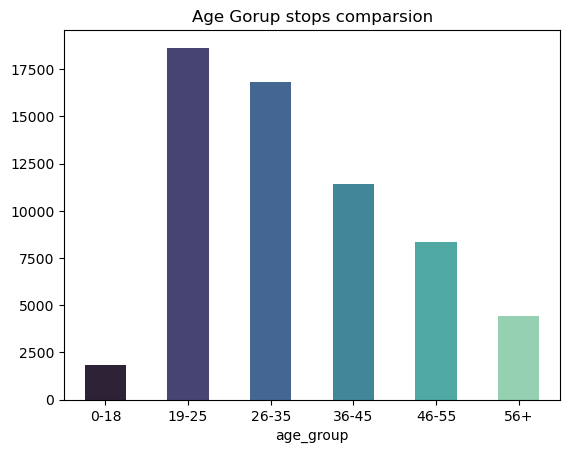

In [51]:
sns.barplot(
    x = result.index,
    y = result.values,
    palette='mako',
    width = 0.5,
    linewidth = 0.5
)
plt.title('Age Gorup stops comparsion')

- 2.Kis age group ka arrest rate sab se zyada hai? 

In [52]:
arrest_rate = df.groupby('age_group', observed=False)['is_arrested'].mean()*100
arrest_rate

age_group
0-18     2.947598
19-25    3.816015
26-35    4.615293
36-45    3.968185
46-55    2.526341
56+      1.242938
Name: is_arrested, dtype: object

- sirf highest arrest rate wala group show kro 

In [53]:
print(f'Highest arrest rate group = {arrest_rate.idxmax()}')
print(f'Arrest Rate = {arrest_rate.max()}')

Highest arrest rate group = 26-35
Arrest Rate = 4.615292996665079


- Kya young drivers ko older drivers se zyada search kiya gaya?

In [54]:
df.head(3)

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,age_group
0,01-02-2005,01:55,M,20.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False,19-25
1,1/18/2005,08:15,M,40.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False,36-45
2,1/23/2005,23:15,M,33.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False,26-35


In [55]:
# create new column named driver_category 
df['driver_category'] = df['driver_age'].apply(lambda x: 'Young' if x<35 else 'Old')

In [56]:
df['driver_category'].value_counts()

driver_category
Young    35947
Old      25527
Name: count, dtype: int64

In [57]:
# ab serch rate compare kro 
category = df.groupby('driver_category')['search_conducted'].mean()*100
category

driver_category
Old      2.789204
Young    4.915570
Name: search_conducted, dtype: float64

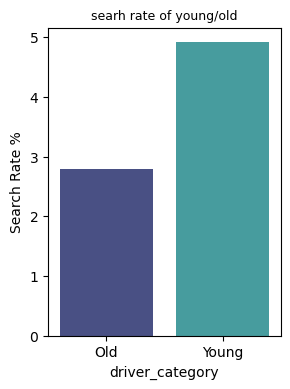

In [58]:
plt.figure(figsize=(3,4))
sns.barplot(x = category.index, y = category.values, palette='mako')
plt.ylabel('Search Rate %')
plt.title('searh rate of young/old', fontsize = 9)
plt.show()

- 4.Kya age aur stop duration ke darmiyan koi relation hai? 

In [60]:
# driver_age numeric hai lekin stop_duration categorical (object) hai.
# Pehle check karo:
df['stop_duration'].value_counts()

stop_duration
0-15 Min     47378
16-30 Min    11448
30+ Min       2647
2                1
Name: count, dtype: int64

In [61]:
# Age ki average har stop duration ke liye nikalo:
df.groupby('stop_duration')['driver_age'].mean()

stop_duration
0-15 Min     34.010849
16-30 Min    34.100716
2            52.000000
30+ Min      36.537968
Name: driver_age, dtype: float64

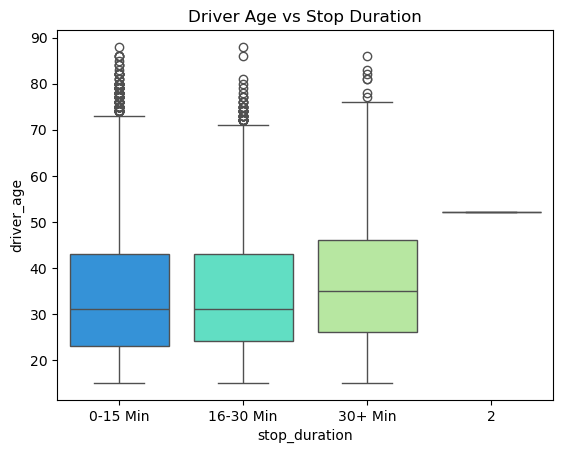

In [62]:
sns.boxplot(x='stop_duration',y='driver_age',data=df,palette='rainbow')
plt.title('Driver Age vs Stop Duration')
plt.show()

- 5.Sab se common violation kis age group mein hoti hai? 

In [63]:
df.head(2)

,stop_date,stop_time,driver_gender,driver_age,driver_race,violation,search_conducted,search_type,stop_outcome,is_arrested,stop_duration,drugs_related_stop,age_group,driver_category
0,01-02-2005,01:55,M,20.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False,19-25,Young
1,1/18/2005,08:15,M,40.0,White,Speeding,False,No Search,Citation,False,0-15 Min,False,36-45,Old


In [74]:
pd.crosstab(df['age_group'], df['violation']).idxmax(axis = 1)

age_group
0-18     Speeding
19-25    Speeding
26-35    Speeding
36-45    Speeding
46-55    Speeding
56+      Speeding
dtype: object

- har age group me sb sy comon violation kosni hy 

In [75]:
pd.crosstab(df['age_group'], df['violation']).idxmax()

violation
Equipment              19-25
Moving violation       26-35
Other                  36-45
Registration/plates    19-25
Seat belt              19-25
Speeding               19-25
dtype: category
Categories (6, object): ['0-18' < '19-25' < '26-35' < '36-45' < '46-55' < '56+']

______________
## Violation Analysis

- 1.Kis violation par sab se zyada arrests hui? 

In [81]:
# method 1 
pd.crosstab(df['violation'], df['is_arrested'])[True]

violation
Equipment              470
Moving violation       710
Other                  256
Registration/plates    276
Seat belt                0
Speeding               548
Name: True, dtype: int64

In [84]:
# method 2
arest = pd.crosstab(df['violation'], df['is_arrested'])[True]
print('violation name = ',arest.idxmax())
print('number of arrests = ', arest.max())      

violation name =  Moving violation
number of arrests =  710


In [85]:
# method 3
df[df['is_arrested']==True]['violation'].value_counts()

violation
Moving violation       710
Speeding               548
Equipment              470
Registration/plates    276
Other                  256
Name: count, dtype: int64

In [86]:
# method 4 -> sirf top violation name
df[df['is_arrested']== True]['violation'].mode()

0    Moving violation
Name: violation, dtype: object


⚠️ Dhyan rahe:

"Sab se zyada arrests hui?" aur "Sab se zyada arrest rate?" alag questions hain.

Total arrests → value_counts()
Highest arrest rate → groupby('violation')['is_arrested'].mean()*100

Dono ko mix mat karna.

- Kis violation par sab se zyada searches hui? 

In [89]:
vio_search = df[df['search_conducted']==True]['violation'].value_counts()
vio_search

violation
Speeding               796
Moving violation       690
Equipment              539
Registration/plates    289
Other                  165
Name: count, dtype: int64

In [88]:
pd.crosstab(df['search_conducted'], df['violation'])

violation,Equipment,Moving violation,Other,Registration/plates,Seat belt,Speeding
search_conducted,,,,,,
False,5977,11236,3418,1954,3,36407
True,539,690,165,289,0,796


Text(0.5, 1.0, 'Arrests by Violation Type')

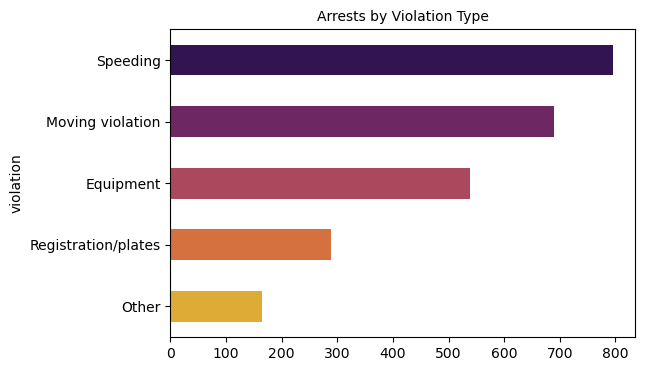

In [101]:
plt.figure(figsize=(6,4))
#vio_search.plot(kind = 'barh', color = 'g')
sns.barplot(y =vio_search.index, x = vio_search.values, width=0.5, palette='inferno')
plt.title('Arrests by Violation Type', fontsize = 10)

- Kis violation mein stop duration sab se lambi hoti hai?

In [112]:
df['stop_duration'].value_counts()

stop_duration
0-15 Min     47378
16-30 Min    11448
30+ Min       2647
2                1
Name: count, dtype: int64

In [115]:
pd.crosstab(df['violation'],df['stop_duration'])['30+ Min']

violation
Equipment               350
Moving violation       1130
Other                   489
Registration/plates     179
Seat belt                 0
Speeding                499
Name: 30+ Min, dtype: int64

In [116]:
long_stop = pd.crosstab(df['violation'],df['stop_duration'])['30+ Min']
print(long_stop.idxmax())

Moving violation
